## CLUSTERIZACIÓN
CESNET TIME SERIES 24 - AGGREGATION 10 MINUTE
- Diferenciar tipos de semanas de una institución
- Diferenciar tipos de instituciones
- Detección de anomalías con los umbrales

In [1]:
# IMPORTS, FUNCIONES Y DIRECTORIOS

# IMPORTS
import pandas as pd
import numpy as np
import os
import tqdm
from scipy.io import savemat
import matplotlib.pyplot as plt
import ast  # Para convertir strings que representan listas a listas reales
import warnings
warnings.filterwarnings("ignore")
import skfda
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.ml.clustering import KMeans
from datetime import datetime
from datetime import date
from skfda.representation.basis import BSplineBasis, FourierBasis
from skfda.misc.metrics import lp_distance
from skfda.representation.grid import FDataGrid
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from sklearn.metrics import silhouette_score
from skfda.misc.metrics import LpDistance

# FUNCIONES
# Ajustar el eje X para mostrar fechas en lugar de segundos Unix
# a) Convertir los valores del eje x (segundos Unix) a un formato numérico
# que Matplotlib pueda interpretar como fecha (días desde el año 0)
# Esto se hace usando la función personalizada UnixConverter.
# Como FDataGrid usa los segundos directamente, la conversión
# debe hacerse en el formateador o usar una aproximación.

# En Matplotlib, `ax.xaxis.set_major_formatter()` es lo que necesitas.
# Usaremos un formateador que convierta los segundos Unix a objetos datetime.
def unix_to_date_formatter(unix_timestamp, pos):
    """
    Formateador de Matplotlib para convertir segundos Unix a fecha.
    """
    # Se añade un pequeño offset si Matplotlib lo requiere, pero generalmente
    # epoch2num es el conversor más limpio para Matplotlib.
    return pd.to_datetime(unix_timestamp, unit='s').strftime('%Y-%m-%d')
    # O para una representación de solo día/mes:
    # return pd.to_datetime(unix_timestamp, unit='s').strftime('%d %b')


def aplicar_mu_law(df, mu=255, col_time="time"):
    def transformar_columna(x):
        x_max = x.abs().max()
        if x_max == 0:
            return x

        x_norm = x / x_max
        x_mu = np.sign(x_norm) * (np.log(1 + mu * np.abs(x_norm)) / np.log(1 + mu))
        return x_mu

    # Separar time
    time = df[col_time]
    data = df.drop(columns=[col_time])

    # Aplicar Mu-Law solo a las señales
    data_mu = data.apply(transformar_columna)

    # Volver a unir time
    data_mu[col_time] = time

    return data_mu


def t_to_datetime_info(t_norm):
    """
    Convierte t ∈ [0,1] a día, hora y minuto reales
    """
    minutes_per_week = 7 * 24 * 60

    total_minutes = t_norm * minutes_per_week

    day_idx = int(total_minutes // (24 * 60))
    day_idx = min(day_idx, 6)  # seguridad numérica

    minutes_in_day = total_minutes % (24 * 60)
    hour = int(minutes_in_day // 60)
    minute = int(minutes_in_day % 60)

    days = ["Lunes", "Martes", "Miércoles",
            "Jueves", "Viernes", "Sábado", "Domingo"]

    return days[day_idx], hour, minute


def t_to_original_index(t_norm, n_points=1008):
    """
    Mapea t ∈ [0,1] al índice original más cercano
    """
    idx = int(round(t_norm * (n_points - 1)))
    return max(0, min(idx, n_points - 1))


def parse_week_column(col_name):
    """
    Ejemplo: 'n_flows_0_41_2023'
    → variable='n_flows_0', week=41, year=2023
    """
    parts = col_name.split("_")
    year = int(parts[-1])
    week = int(parts[-2])
    variable = "_".join(parts[:-2])
    return variable, week, year

def get_week_mask(df_ts, week, year):
    return (
        (df_ts.index.isocalendar().week == week) &
        (df_ts.index.isocalendar().year == year)
    )


# DIRECTORIOS
DATASET_PATH = r"C:\Users\itsal\Desktop\MASTER\TFM\CESNET\CESNET_TimeSeries24"

IP_ADDRESSES_SAMPLE = os.path.join(DATASET_PATH, "ip_addresses_sample")
INSTITUTIONS = os.path.join(DATASET_PATH, "institutions")
INSTITUTION_SUBNETS = os.path.join(DATASET_PATH, "institution_subnets")
##IP_ADDRESSES_FULL = os.path.join(DATASET_PATH, "ip_addresses_full")


TIMES_10_MINUTES = os.path.join(DATASET_PATH, "times", "times_10_minutes.csv")
TIMES_1_HOUR = os.path.join(DATASET_PATH, "times", "times_1_hour.csv")
TIMES_1_DAY = os.path.join(DATASET_PATH, "times", "times_1_day.csv")


# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar
agg_1_day_path = os.path.join(INSTITUTIONS, "agg_1_day")
agg_1_hour_path = os.path.join(INSTITUTIONS, "agg_1_hour")
agg_10_minutes_path = os.path.join(INSTITUTIONS, "agg_10_minutes_filtrado")
# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar

In [2]:
# VARIABLES PARA USAR
file_path = os.path.join(agg_10_minutes_path, os.listdir(agg_10_minutes_path)[0])
df_TS24 = pd.read_csv(file_path)
print(df_TS24.columns[1:].tolist())


['n_flows', 'n_packets', 'n_bytes', 'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn', 'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports', 'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip', 'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes', 'avg_duration', 'avg_ttl']


In [3]:
# INSITUCIONES DISPONIBLES
csv_files = [
    f for f in os.listdir(agg_10_minutes_path)
    if f.endswith(".csv")
]

print(csv_files)



['0.csv', '10.csv', '108.csv', '109.csv', '113.csv', '139.csv', '145.csv', '147.csv', '161.csv', '175.csv', '198.csv', '216.csv', '223.csv', '224.csv', '23.csv', '230.csv', '235.csv', '243.csv', '244.csv', '249.csv', '34.csv', '42.csv', '48.csv', '50.csv', '53.csv', '55.csv', '56.csv', '57.csv', '59.csv', '62.csv', '68.csv', '69.csv', '70.csv', '80.csv', '86.csv', '93.csv']


In [4]:
# ELECCIÓN DE VARIABLE E INSTITUCIÓN
variable = "n_packets"
institucion = "0.csv"

In [5]:
# FICHERO Y COMPANDING
# Rutas
fpath = os.path.join(agg_10_minutes_path, institucion)

# Leer mapping id_time → time
times_df = pd.read_csv(TIMES_10_MINUTES)

# Rutas
fpath = os.path.join(agg_10_minutes_path, institucion)

# Leer mapping id_time → time
times_df = pd.read_csv(TIMES_10_MINUTES)

# Leer solo el CSV que nos interesa
df_TS24_insititucion = pd.read_csv(fpath)

# Comprobar que la variable existe
if variable not in df_TS24_insititucion.columns:
    raise ValueError(f"La variable '{variable}' no existe en {institucion}")

# Merge para sustituir id_time por time
df_TS24_insititucion = (
    df_TS24_insititucion.merge(times_df, on="id_time", how="left")
      .drop(columns=["id_time"])
)
# Renombrar la columna como n_flows_0
new_col = f"{variable}_{institucion.replace('.csv','')}"

df_TS24_insititucion = df_TS24_insititucion[["time", variable]].rename(columns={variable: new_col})

# Convertir time a datetime y eliminar zona horaria
df_TS24_insititucion["time"] = pd.to_datetime(df_TS24_insititucion["time"], utc=True).dt.tz_localize(None)


# COMPANDING Y PASAR DE DATOS ESCALARES A FUNCIONALES (FOURIER)
df_TS24_companded = aplicar_mu_law(df_TS24_insititucion)
cols = ['time'] + [c for c in df_TS24_companded.columns if c != 'time']
df_TS24_companded = df_TS24_companded[cols]

df_TS24_companded

,time,n_packets_0
0,2023-10-09 00:03:49,0.556011
1,2023-10-09 00:13:49,0.612719
2,2023-10-09 00:23:49,0.529257
3,2023-10-09 00:33:49,0.545362
4,2023-10-09 00:43:49,0.550940
...,...,...
40293,2024-07-14 21:10:52,0.665485
40294,2024-07-14 21:20:52,0.689312
40295,2024-07-14 21:30:52,0.732208
40296,2024-07-14 21:40:52,0.653425


In [6]:
# SEMANAS DISPONIBLES
groups_week = dict(
    tuple(
        df_TS24_companded.groupby(
            [
                df_TS24_companded["time"].dt.isocalendar().year,
                df_TS24_companded["time"].dt.isocalendar().week,
            ]
        )
    )
)

# Semanas disponibles (AÑO, SEMANA)
semanas_disponibles = [(int(a), int(b)) for a, b in groups_week]
print(semanas_disponibles)


[(2023, 41), (2023, 42), (2023, 43), (2023, 44), (2023, 45), (2023, 46), (2023, 47), (2023, 48), (2023, 49), (2023, 50), (2023, 51), (2023, 52), (2024, 1), (2024, 2), (2024, 3), (2024, 4), (2024, 5), (2024, 6), (2024, 7), (2024, 8), (2024, 9), (2024, 10), (2024, 11), (2024, 12), (2024, 13), (2024, 14), (2024, 15), (2024, 16), (2024, 17), (2024, 18), (2024, 19), (2024, 20), (2024, 21), (2024, 22), (2024, 23), (2024, 24), (2024, 25), (2024, 26), (2024, 27), (2024, 28)]


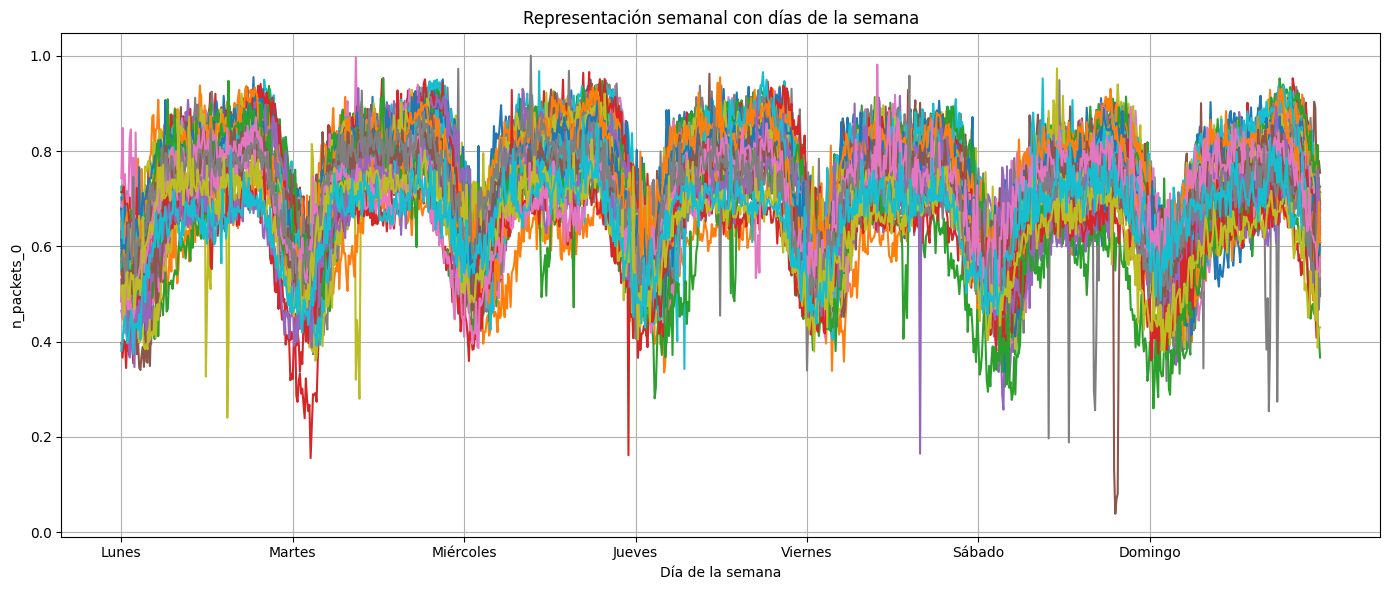

,n_packets_0_41_2023,n_packets_0_42_2023,n_packets_0_43_2023,n_packets_0_44_2023,n_packets_0_45_2023,n_packets_0_46_2023,n_packets_0_47_2023,n_packets_0_48_2023,n_packets_0_49_2023,n_packets_0_50_2023,...,n_packets_0_19_2024,n_packets_0_20_2024,n_packets_0_21_2024,n_packets_0_22_2024,n_packets_0_23_2024,n_packets_0_24_2024,n_packets_0_25_2024,n_packets_0_26_2024,n_packets_0_27_2024,n_packets_0_28_2024
0,0.556011,0.609480,0.549427,0.678533,0.668763,0.682168,0.742954,0.614079,0.723969,0.725587,...,0.613651,0.543080,0.582522,0.397326,0.464661,0.484525,0.496956,0.566050,0.495936,0.380174
1,0.612719,0.728652,0.541554,0.664449,0.613760,0.653342,0.848537,0.652039,0.668322,0.695635,...,0.573658,0.530750,0.560446,0.366353,0.451885,0.554196,0.446733,0.582805,0.518806,0.400646
2,0.529257,0.616380,0.576991,0.660761,0.707351,0.686775,0.684819,0.587157,0.660500,0.689444,...,0.602296,0.591883,0.549168,0.403835,0.474241,0.510764,0.498204,0.574859,0.429805,0.433742
3,0.545362,0.566197,0.541016,0.685284,0.734166,0.634592,0.730025,0.523346,0.668982,0.685812,...,0.582563,0.568739,0.499957,0.399608,0.511719,0.531607,0.417852,0.546741,0.519970,0.453899
4,0.550940,0.655896,0.598077,0.630269,0.651545,0.624568,0.673699,0.574771,0.669047,0.715490,...,0.616952,0.540195,0.480850,0.344491,0.417446,0.486341,0.577047,0.582083,0.515802,0.422408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,0.647799,0.624615,NaN,0.735795,0.775653,0.890397,0.663877,0.731800,0.752083,0.769259,...,0.596415,0.584218,0.496765,0.476288,0.523606,0.526707,0.609221,0.542120,0.444748,NaN
1004,0.589268,0.531128,NaN,0.677874,0.717443,0.754433,0.625345,0.741366,0.781181,0.766703,...,0.600382,0.580584,0.511536,0.408256,0.555796,0.518597,0.589952,0.520790,0.548486,NaN
1005,0.646395,0.602045,NaN,0.666297,0.721264,0.776338,0.690429,0.755357,0.732735,0.736264,...,0.573627,0.601670,0.438735,0.489901,0.501939,0.495866,0.535528,0.543806,0.387065,NaN
1006,0.609552,0.560975,NaN,0.742872,0.666440,0.779598,0.622374,0.696593,0.718102,0.692986,...,0.579675,0.693626,0.410448,0.526151,0.550174,0.581515,0.515986,0.466854,0.425893,NaN


In [7]:
# SEPARAR DF EN SEMANAS 
# Extraer año ISO y semana ISO
iso = df_TS24_companded['time'].dt.isocalendar()
df_TS24_companded['iso_year'] = iso.year
df_TS24_companded['iso_week'] = iso.week

# Nombre de la segunda columna
second_col = df_TS24_companded.columns[1]

# Diccionario para columnas
weekly_data = {}

# Agrupar por año ISO y semana ISO
for (year, week), group in df_TS24_companded.groupby(['iso_year', 'iso_week']):
    col_name = f"{second_col}_{int(week):02d}_{int(year)}"
    weekly_data[col_name] = group[second_col].reset_index(drop=True)

# Crear DataFrame final
df_weeks = pd.DataFrame(weekly_data)


# ---------------------------
# Crear eje X en horas y días
# ---------------------------
n_time = df_weeks.shape[0]
minutes_per_step = 10
x_hours = np.arange(n_time) * minutes_per_step / 60  # horas acumuladas

days = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
ticks = np.arange(0, 7*24, 24)  # cada 24 horas


plt.figure(figsize=(14, 6))

for col in df_weeks.columns:
    plt.plot(x_hours, df_weeks[col], label=col)

plt.xlabel("Día de la semana")
plt.ylabel(df_TS24_companded.columns[1])
plt.title("Representación semanal con días de la semana")

plt.xticks(ticks, days)
plt.grid(True)
plt.tight_layout()
plt.show()


df_weeks


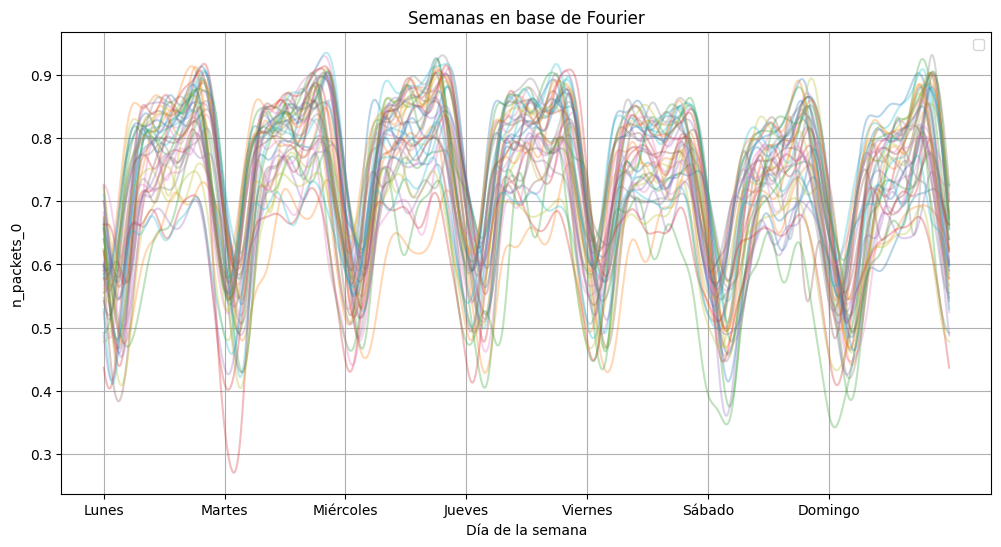

In [8]:
# PASAR A DATOS FUNCIONALES Y REPRESENTACION

# ---------------------------
# 1️⃣ Limpiar DataFrame
# ---------------------------
df_weeks_clean = (
    df_weeks
    .interpolate(axis=0, limit_direction='both')
    .fillna(method='bfill')
    .fillna(method='ffill')
)

# ---------------------------
# 2️⃣ Crear base de Fourier
# ---------------------------
n_time = df_weeks_clean.shape[0]   # puntos por semana
t = np.linspace(0, 1, n_time)      # dominio normalizado
n_basis = 70                       # AJUSTADO CON MIRANDO EL CODO DEL MSE

basis = FourierBasis(domain_range=(0, 1), n_basis=n_basis)

fd = FDataGrid(
    data_matrix=df_weeks_clean.T.values,
    grid_points=t
)

fd_fourier = fd.to_basis(basis)

# ---------------------------
# 3️⃣ Evaluar funciones en la rejilla temporal
# ---------------------------
X = fd_fourier(t).squeeze()   # shape: (n_semanas, n_time)

# ---------------------------
# 4️⃣ Crear eje x en horas
# ---------------------------
minutes_per_step = 10
x_hours = np.arange(n_time) * minutes_per_step / 60  # tiempo en horas

# Etiquetas de los días
days = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
hours_per_day = 24
ticks = np.arange(0, 7*24, 24)  # 0, 24, 48, 72, 96, 120, 144 → 7 ticks

# ---------------------------
# 5️⃣ Plot de semanas superpuestas
# ---------------------------
plt.figure(figsize=(12, 6))

for week_curve in X:
    plt.plot(x_hours, week_curve, alpha=0.3)  # todas las semanas semi-transparente

plt.title("Semanas en base de Fourier")
plt.xlabel("Día de la semana")
plt.ylabel(df_TS24_companded.columns[1])
plt.xticks(ticks, days)
plt.grid(True)
plt.legend()
plt.show()


FUNCTIONAL K-MEANS - Diferenciar tipos de semanas de una institución

Mejor coeficiente de silueta: 0.301
PDF guardado como: clusters_funcionales.pdf


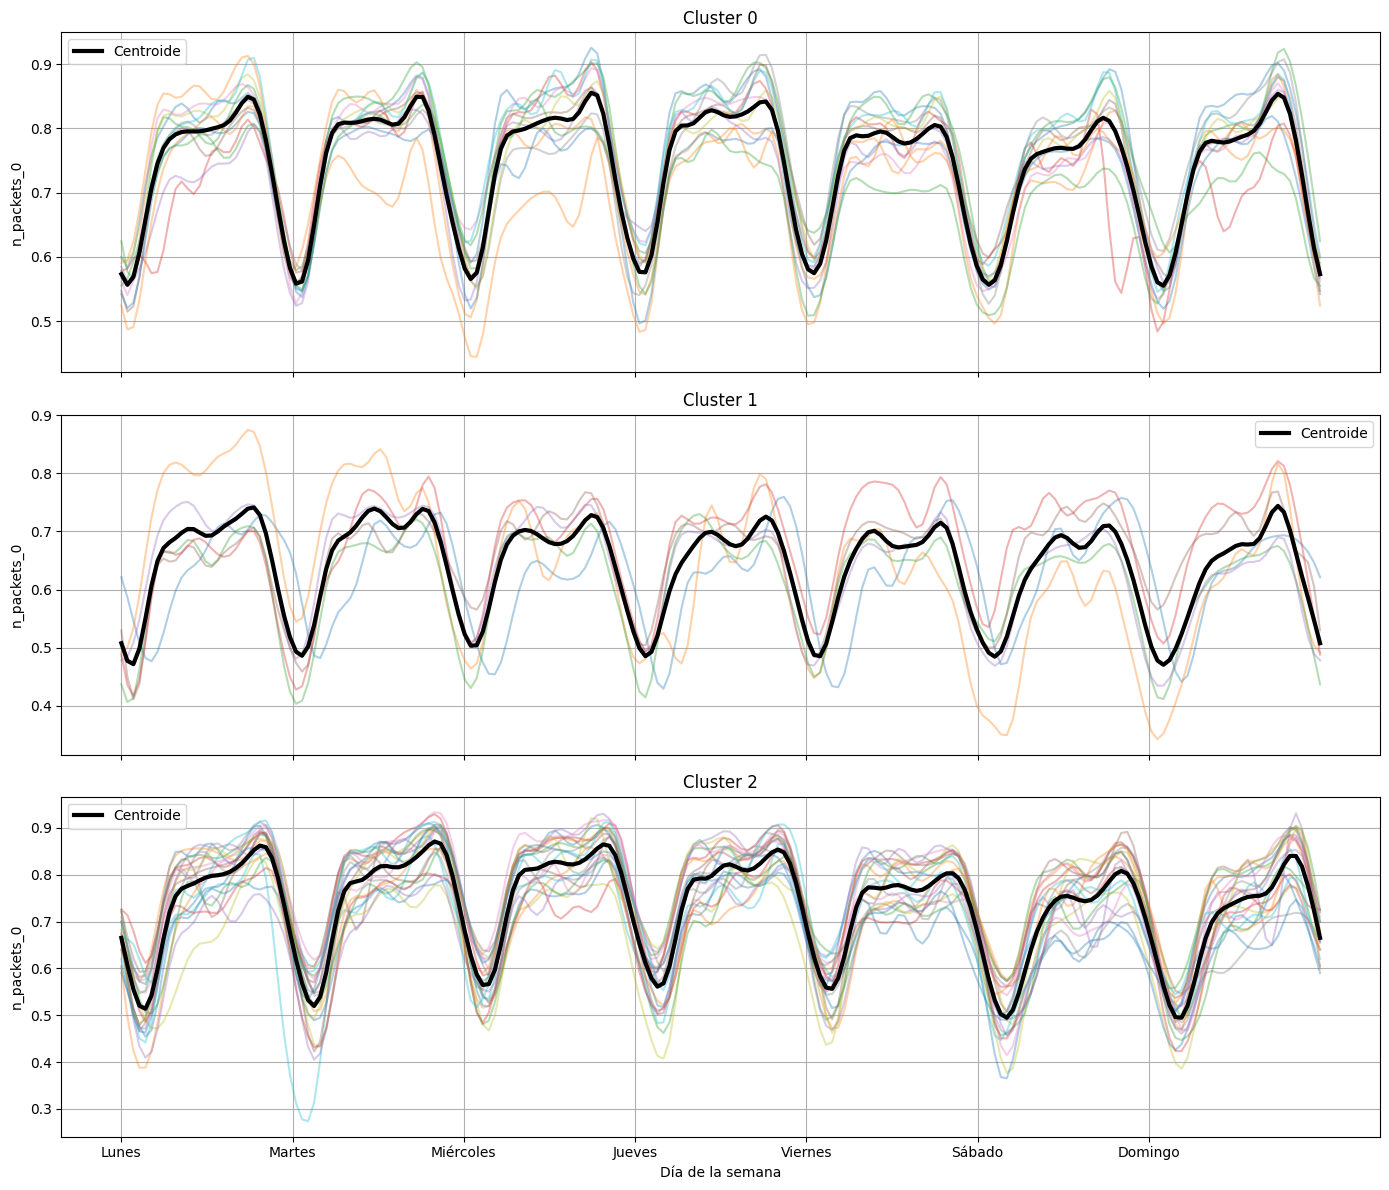


Cluster 0: 13 curvas
Curvas: ['n_packets_0_41_2023', 'n_packets_0_42_2023', 'n_packets_0_43_2023', 'n_packets_0_14_2024', 'n_packets_0_15_2024', 'n_packets_0_16_2024', 'n_packets_0_17_2024', 'n_packets_0_18_2024', 'n_packets_0_19_2024', 'n_packets_0_20_2024', 'n_packets_0_24_2024', 'n_packets_0_25_2024', 'n_packets_0_26_2024']

Cluster 1: 6 curvas
Curvas: ['n_packets_0_52_2023', 'n_packets_0_21_2024', 'n_packets_0_22_2024', 'n_packets_0_23_2024', 'n_packets_0_27_2024', 'n_packets_0_28_2024']

Cluster 2: 21 curvas
Curvas: ['n_packets_0_44_2023', 'n_packets_0_45_2023', 'n_packets_0_46_2023', 'n_packets_0_47_2023', 'n_packets_0_48_2023', 'n_packets_0_49_2023', 'n_packets_0_50_2023', 'n_packets_0_51_2023', 'n_packets_0_01_2024', 'n_packets_0_02_2024', 'n_packets_0_03_2024', 'n_packets_0_04_2024', 'n_packets_0_05_2024', 'n_packets_0_06_2024', 'n_packets_0_07_2024', 'n_packets_0_08_2024', 'n_packets_0_09_2024', 'n_packets_0_10_2024', 'n_packets_0_11_2024', 'n_packets_0_12_2024', 'n_packets_

In [9]:
# FUNCTIONAL K-MEANS CON COEF.SILUETA Y DISTANCIA L^2
# ============================================================
# 4) PREPARACIÓN PARA FUNCTIONAL K-MEANS
# ============================================================

# Grilla de evaluación más fina (dominio normalizado 0–1)
t_eval = np.linspace(0, 1, 200)

# Evaluar las funciones suavizadas en la nueva grilla
fd_suavizado_grid = fd_fourier.evaluate(t_eval).squeeze()
# shape: (n_semanas, len(t_eval))

fd_suavizado = skfda.FDataGrid(
    data_matrix=fd_suavizado_grid,
    grid_points=t_eval
)


# ============================================================
# 5) FUNCTIONAL K-MEANS + SELECCIÓN POR SILUETA
# ============================================================

n_clusters = 3
metric = LpDistance(p=2)
n_init = 10

best_score = -1
best_fkmeans = None

# Aplanado para silhouette (sklearn no es funcional)
X_flat = fd_suavizado.data_matrix.reshape(
    fd_suavizado.data_matrix.shape[0], -1
)

for seed in range(n_init):

    fkmeans = KMeans(
        n_clusters=n_clusters,
        metric=metric,
        random_state=seed
    )
    fkmeans.fit(fd_suavizado)

    labels = fkmeans.labels_
    score = silhouette_score(X_flat, labels, metric="euclidean")

    if score > best_score:
        best_score = score
        best_fkmeans = fkmeans


labels = best_fkmeans.labels_
centroids = best_fkmeans.cluster_centers_

print(f"Mejor coeficiente de silueta: {best_score:.3f}")


# ============================================================
# 6) PLOT DE CURVAS POR CLUSTER (3 SUBPLOTS EN UN MISMO PDF)
# ============================================================

from matplotlib.backends.backend_pdf import PdfPages

# Eje temporal en horas
minutes_per_step = 10
x_hours_eval = t_eval * (7 * 24)

# Crear figura con 3 subplots
fig, axes = plt.subplots(
    n_clusters,
    1,
    figsize=(14, 12),
    sharex=True
)

# Si solo hubiese un cluster
if n_clusters == 1:
    axes = [axes]

for i, ax in enumerate(axes):

    ax.set_title(f"Cluster {i}")

    idx_cluster = np.where(labels == i)[0]

    # Curvas del cluster
    for idx in idx_cluster:
        y = fd_suavizado.data_matrix[idx].squeeze()

        ax.plot(
            x_hours_eval,
            y,
            alpha=0.35
        )

    # Centroide
    centroid_eval = centroids[i].evaluate(t_eval).squeeze()

    ax.plot(
        x_hours_eval,
        centroid_eval,
        color="black",
        linewidth=3,
        label="Centroide"
    )

    # Configuración ejes
    ax.set_ylabel(df_TS24_companded.columns[1])
    ax.grid(True)
    ax.legend()

# Etiquetas eje X (solo abajo)
days = [
    "Lunes", "Martes", "Miércoles", "Jueves",
    "Viernes", "Sábado", "Domingo"
]

ticks = np.arange(0, 7 * 24, 24)

axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels(days)
axes[-1].set_xlabel("Día de la semana")

plt.tight_layout()

# ============================================================
# GUARDAR EN PDF
# ============================================================

pdf_filename = "clusters_funcionales.pdf"

with PdfPages(pdf_filename) as pdf:
    pdf.savefig(fig, bbox_inches="tight")

print(f"PDF guardado como: {pdf_filename}")

plt.show()

# ============================================================
# 7) INFORMACIÓN DE CLUSTERS (NOMBRES DE CURVAS)
# ============================================================

for i in range(n_clusters):
    cluster_idx = np.where(labels == i)[0]
    cluster_cols = df_weeks_clean.columns[cluster_idx].tolist()

    print(f"\nCluster {i}: {len(cluster_idx)} curvas")
    print("Curvas:", cluster_cols)



CLUSTER 0
→ 144 anomalías detectadas

CLUSTER 1
→ 79 anomalías detectadas

CLUSTER 2
→ 117 anomalías detectadas

PDF guardado como: anomalias_clusters.pdf


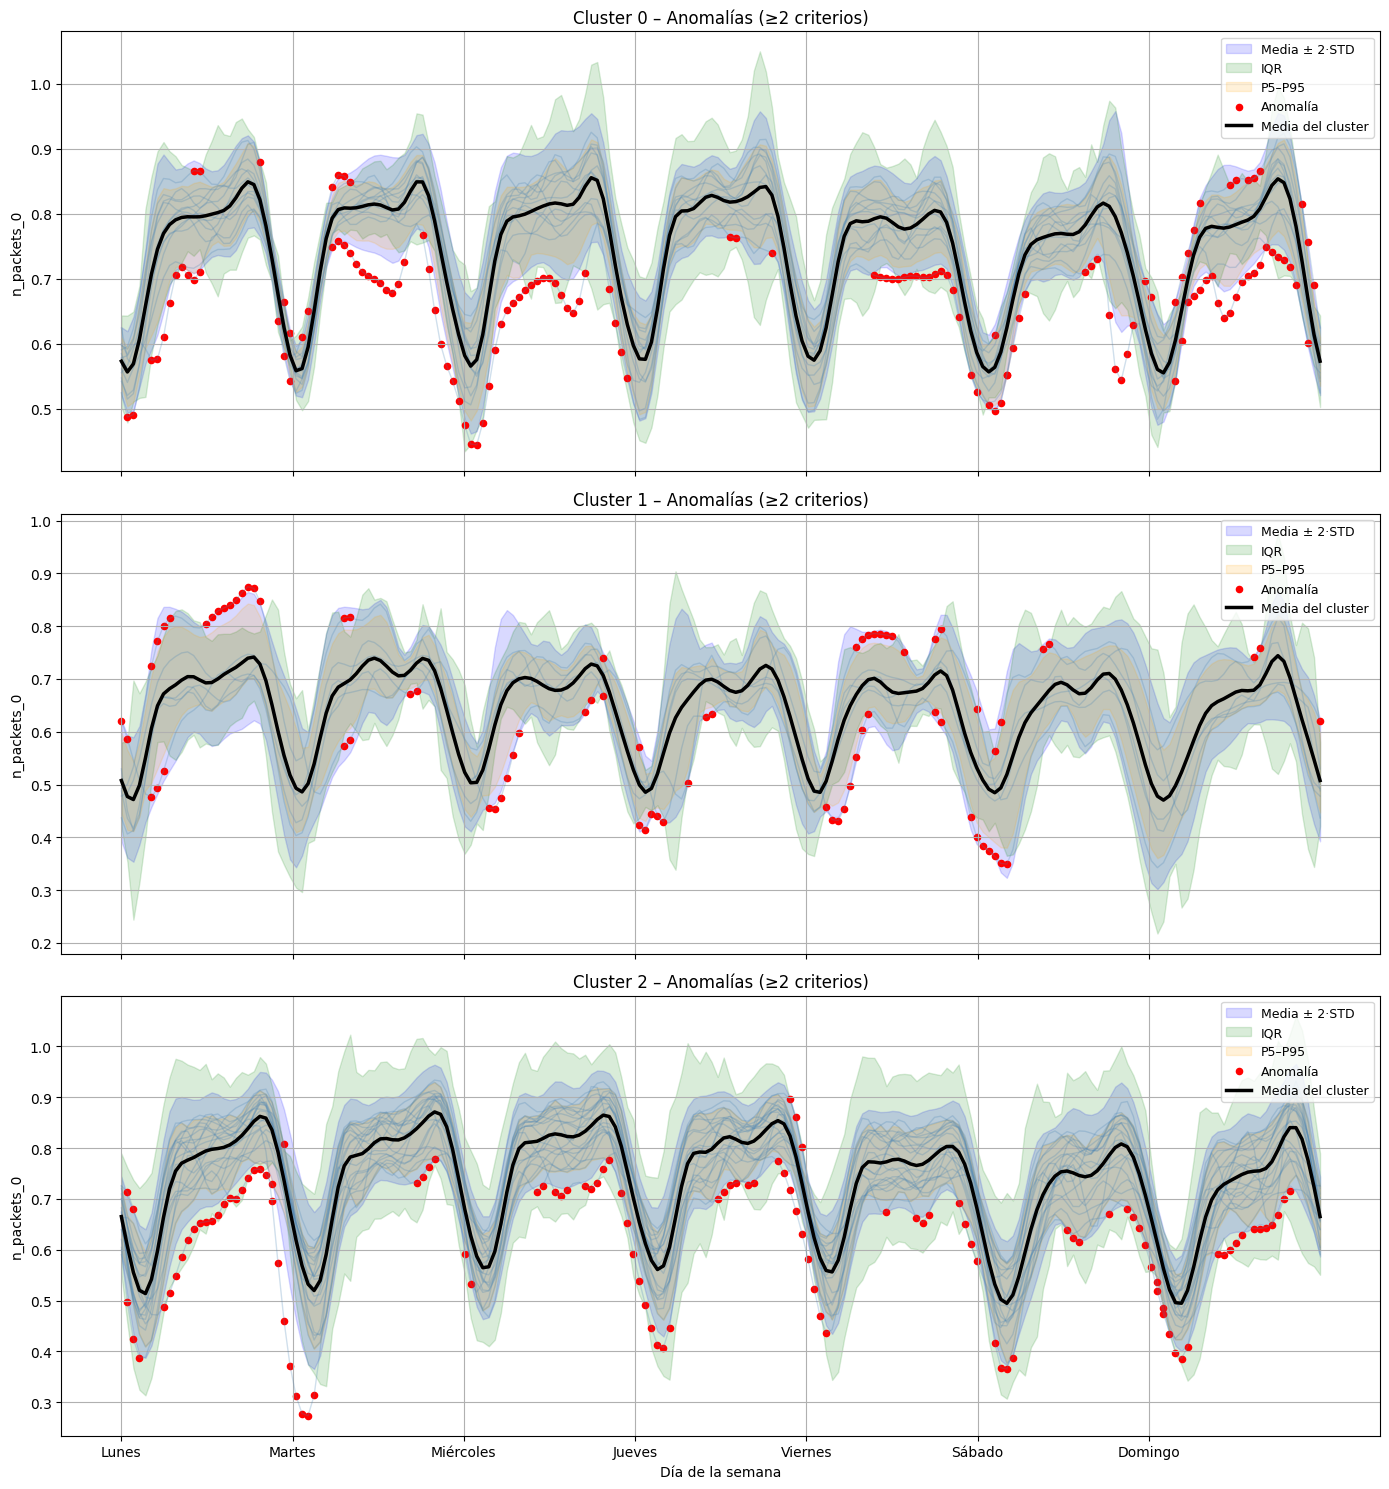


DataFrame final de anomalías:
   cluster         nombre_curva  indice_anomalia
0        0  n_packets_0_41_2023              178
1        0  n_packets_0_41_2023              179
2        0  n_packets_0_41_2023              184
3        0  n_packets_0_41_2023              185
4        0  n_packets_0_41_2023              187


In [17]:
# ==========================================================
# DETECCIÓN DE ANOMALÍAS POR CLUSTER
# + PLOT MULTI-CLUSTER EN UNA SOLA FIGURA
# + EXPORTACIÓN A PDF
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.backends.backend_pdf import PdfPages

# ==========================================================
# PARÁMETROS
# ==========================================================

k = 2
percentil_low = 5
percentil_high = 95

anomalies_by_cluster = {}

# ==========================================================
# FIGURA ÚNICA CON SUBPLOTS
# ==========================================================

fig, axes = plt.subplots(
    n_clusters,
    1,
    figsize=(14, 5 * n_clusters),
    sharex=True
)

if n_clusters == 1:
    axes = [axes]

# ==========================================================
# DÍAS DE LA SEMANA
# ==========================================================

days = [
    "Lunes", "Martes", "Miércoles",
    "Jueves", "Viernes",
    "Sábado", "Domingo"
]

ticks = np.arange(0, 7 * 24, 24)

# ==========================================================
# LOOP POR CLUSTERS
# ==========================================================

for c, ax in enumerate(axes):

    print("\n==============================")
    print(f"CLUSTER {c}")
    print("==============================")

    # ======================================================
    # DATOS DEL CLUSTER
    # ======================================================

    idx_cluster = np.where(labels == c)[0]
    Xc = fd_suavizado.data_matrix[idx_cluster].squeeze()

    n_curvas, n_time = Xc.shape

    # ======================================================
    # 1️⃣ UMBRALES
    # ======================================================

    mean_curve = Xc.mean(axis=0)
    std_curve = Xc.std(axis=0)

    upper_std = mean_curve + k * std_curve
    lower_std = mean_curve - k * std_curve

    Q1 = np.percentile(Xc, 25, axis=0)
    Q3 = np.percentile(Xc, 75, axis=0)

    IQR = Q3 - Q1

    upper_iqr = Q3 + 1.5 * IQR
    lower_iqr = Q1 - 1.5 * IQR

    upper_p95 = np.percentile(Xc, percentil_high, axis=0)
    lower_p5 = np.percentile(Xc, percentil_low, axis=0)

    # ======================================================
    # 2️⃣ DETECCIÓN
    # ======================================================

    anomalies_std = (Xc > upper_std) | (Xc < lower_std)
    anomalies_iqr = (Xc > upper_iqr) | (Xc < lower_iqr)
    anomalies_p95 = (Xc > upper_p95) | (Xc < lower_p5)

    # ======================================================
    # 3️⃣ DECISOR FINAL (≥2 CRITERIOS)
    # ======================================================

    anomalies_decided = (
        anomalies_std.astype(int)
        + anomalies_iqr.astype(int)
        + anomalies_p95.astype(int)
    ) >= 2

    # ======================================================
    # 4️⃣ DATAFRAME DE ANOMALÍAS
    # ======================================================

    records = []

    for i in range(n_curvas):

        idxs = np.where(anomalies_decided[i])[0]

        if len(idxs) > 0:

            curva_global = idx_cluster[i]

            nombre_curva = df_weeks_clean.columns[curva_global]

            for j in idxs:

                records.append({
                    "cluster": c,
                    "nombre_curva": nombre_curva,
                    "indice_anomalia": j
                })

    anomalies_by_cluster[c] = pd.DataFrame(records)

    print(f"→ {len(anomalies_by_cluster[c])} anomalías detectadas")

    # ======================================================
    # 5️⃣ PLOT DEL CLUSTER
    # ======================================================

    ax.set_title(f"Cluster {c} – Anomalías (≥2 criterios)")

    # ---------- BANDAS ----------
    ax.fill_between(
        x_hours_eval,
        lower_std,
        upper_std,
        color="blue",
        alpha=0.15,
        label=f"Media ± {k}·STD"
    )

    ax.fill_between(
        x_hours_eval,
        lower_iqr,
        upper_iqr,
        color="green",
        alpha=0.15,
        label="IQR"
    )

    ax.fill_between(
        x_hours_eval,
        lower_p5,
        upper_p95,
        color="orange",
        alpha=0.15,
        label=f"P{percentil_low}–P{percentil_high}"
    )

    # ---------- CURVAS ----------

    for i in range(n_curvas):

        ax.plot(
            x_hours_eval,
            Xc[i],
            color="steelblue",
            alpha=0.25,
            linewidth=1
        )

        ax.scatter(
            x_hours_eval[anomalies_decided[i]],
            Xc[i][anomalies_decided[i]],
            color="red",
            s=20,
            label="Anomalía" if i == 0 else ""
        )

    # ---------- MEDIA ----------
    ax.plot(
        x_hours_eval,
        mean_curve,
        color="black",
        linewidth=2.5,
        label="Media del cluster"
    )

    ax.grid(True)
    ax.set_ylabel(df_TS24_companded.columns[1])
    ax.legend(loc="upper right", fontsize=9)

# ==========================================================
# EJE X (SOLO ABAJO)
# ==========================================================

axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels(days)
axes[-1].set_xlabel("Día de la semana")

# ==========================================================
# AJUSTE FINAL
# ==========================================================

plt.tight_layout()

# ==========================================================
# GUARDADO EN PDF
# ==========================================================

pdf_filename = "anomalias_clusters.pdf"

with PdfPages(pdf_filename) as pdf:
    pdf.savefig(fig, bbox_inches="tight")

print(f"\nPDF guardado como: {pdf_filename}")

# ==========================================================
# MOSTRAR FIGURA
# ==========================================================

plt.show()

# ==========================================================
# DATAFRAME FINAL
# ==========================================================

df_all_anomalies = pd.concat(
    anomalies_by_cluster.values(),
    ignore_index=True
)

print("\nDataFrame final de anomalías:")
print(df_all_anomalies.head())

In [13]:
# DF CON ANOMALIAS IDENTIFICADAS
records = []

for _, row in df_all_anomalies.iterrows():

    col_name = row["nombre_curva"]
    index_val = row["indice_anomalia"]
    cluster = row["cluster"]

    # =========================
    # 1️⃣ Extraer semana y año
    # =========================

    parts = col_name.split("_")

    try:
        semana = int(parts[-2])
        anio = int(parts[-1])
    except ValueError:
        # Si no se puede parsear, guardamos NaT
        records.append({
            "cluster": cluster,
            "nombre_curva": col_name,
            "indice_anomalia": index_val,
            "timestamp_real": pd.NaT
        })
        continue

    # =========================
    # 2️⃣ Valor semanal
    # =========================

    try:
        valor = df_weeks.loc[index_val, col_name]
    except KeyError:
        records.append({
            "cluster": cluster,
            "nombre_curva": col_name,
            "indice_anomalia": index_val,
            "timestamp_real": pd.NaT
        })
        continue

    # =========================
    # 3️⃣ Filtrado por semana/año
    # =========================

    df_filtrado = df_TS24_companded[
        (df_TS24_companded["time"].dt.isocalendar().week == semana) &
        (df_TS24_companded["time"].dt.year == anio)
    ]

    # =========================
    # 4️⃣ Búsqueda del timestamp
    # =========================

    # Columna base: n_flows_0
    col_base = "_".join(parts[:3])  # 'n_flows_0'

    tiempos = df_filtrado[df_filtrado[col_base] == valor]["time"]

    timestamp_real = tiempos.iloc[0] if len(tiempos) > 0 else pd.NaT

    # =========================
    # 5️⃣ Guardamos resultado
    # =========================

    records.append({
        "cluster": cluster,
        "nombre_curva": col_name,
        "indice_anomalia": index_val,
        "timestamp_real": timestamp_real
    })

# =========================
# 6️⃣ DataFrame final
# =========================

df_anomalies_with_time = pd.DataFrame(records)
df_anomalies_with_time

,cluster,nombre_curva,indice_anomalia,timestamp_real
0,0,n_packets_0_41_2023,178,2023-10-10 05:43:49
1,0,n_packets_0_41_2023,179,2023-10-10 05:53:49
2,0,n_packets_0_41_2023,184,2023-10-10 06:43:49
3,0,n_packets_0_41_2023,185,2023-10-10 06:53:49
4,0,n_packets_0_41_2023,187,2023-10-10 07:13:49
...,...,...,...,...
335,2,n_packets_0_13_2024,140,2024-03-25 23:20:52
336,2,n_packets_0_13_2024,141,2024-03-25 23:30:52
337,2,n_packets_0_13_2024,142,2024-03-25 23:40:52
338,2,n_packets_0_13_2024,157,2024-03-26 02:10:52


FUNCTIONAL K-MEANS - Diferenciar tipos de instituciones en una semana

In [29]:
# ============================================================
# IMPORTS, FUNCIONES Y DIRECTORIOS
# ============================================================

# IMPORTS
import pandas as pd
import numpy as np
import os
import tqdm
from scipy.io import savemat
import matplotlib.pyplot as plt
import ast
import warnings

warnings.filterwarnings("ignore")

import skfda
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.ml.clustering import KMeans
from datetime import datetime
from datetime import date
from skfda.representation.basis import BSplineBasis, FourierBasis
from skfda.misc.metrics import lp_distance
from skfda.representation.grid import FDataGrid
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from sklearn.metrics import silhouette_score
from skfda.misc.metrics import LpDistance

# ============================================================
# FUNCIONES
# ============================================================

def unix_to_date_formatter(unix_timestamp, pos):
    """
    Formateador de Matplotlib para convertir segundos Unix a fecha.
    """
    return pd.to_datetime(unix_timestamp, unit='s').strftime('%Y-%m-%d')


def aplicar_mu_law(df, mu=255, col_time="time"):

    def transformar_columna(x):

        x_max = x.abs().max()

        if x_max == 0:
            return x

        x_norm = x / x_max

        x_mu = np.sign(x_norm) * (
            np.log(1 + mu * np.abs(x_norm)) / np.log(1 + mu)
        )

        return x_mu

    # Separar time
    time = df[col_time]

    # Datos sin time
    data = df.drop(columns=[col_time])

    # Aplicar Mu-Law
    data_mu = data.apply(transformar_columna)

    # Volver a añadir time
    data_mu[col_time] = time

    return data_mu


def t_to_datetime_info(t_norm):

    minutes_per_week = 7 * 24 * 60

    total_minutes = t_norm * minutes_per_week

    day_idx = int(total_minutes // (24 * 60))
    day_idx = min(day_idx, 6)

    minutes_in_day = total_minutes % (24 * 60)

    hour = int(minutes_in_day // 60)
    minute = int(minutes_in_day % 60)

    days = [
        "Lunes",
        "Martes",
        "Miércoles",
        "Jueves",
        "Viernes",
        "Sábado",
        "Domingo"
    ]

    return days[day_idx], hour, minute


def t_to_original_index(t_norm, n_points=1008):

    idx = int(round(t_norm * (n_points - 1)))

    return max(0, min(idx, n_points - 1))


def parse_week_column(col_name):

    parts = col_name.split("_")

    year = int(parts[-1])
    week = int(parts[-2])

    variable = "_".join(parts[:-2])

    return variable, week, year


def get_week_mask(df_ts, week, year):

    return (
        (df_ts.index.isocalendar().week == week) &
        (df_ts.index.isocalendar().year == year)
    )


# ============================================================
# DIRECTORIOS
# ============================================================

DATASET_PATH = r"C:\Users\itsal\Desktop\MASTER\TFM\CESNET\CESNET_TimeSeries24"

IP_ADDRESSES_SAMPLE = os.path.join(DATASET_PATH, "ip_addresses_sample")
INSTITUTIONS = os.path.join(DATASET_PATH, "institutions")
INSTITUTION_SUBNETS = os.path.join(DATASET_PATH, "institution_subnets")

TIMES_10_MINUTES = os.path.join(
    DATASET_PATH,
    "times",
    "times_10_minutes.csv"
)

TIMES_1_HOUR = os.path.join(
    DATASET_PATH,
    "times",
    "times_1_hour.csv"
)

TIMES_1_DAY = os.path.join(
    DATASET_PATH,
    "times",
    "times_1_day.csv"
)

# ============================================================
# SELECCIÓN DE DIRECTORIO
# ============================================================

agg_1_day_path = os.path.join(INSTITUTIONS, "agg_1_day")
agg_1_hour_path = os.path.join(INSTITUTIONS, "agg_1_hour")
agg_10_minutes_path = os.path.join(INSTITUTIONS, "agg_10_minutes_filtrado")

# ============================================================
# VER VARIABLES DISPONIBLES
# ============================================================

file_path = os.path.join(
    agg_10_minutes_path,
    os.listdir(agg_10_minutes_path)[0]
)

df_TS24 = pd.read_csv(file_path)

print("Variables disponibles:")
print(df_TS24.columns[1:].tolist())

# ============================================================
# CSV DISPONIBLES
# ============================================================

csv_files = [
    f for f in os.listdir(agg_10_minutes_path)
    if f.endswith(".csv")
]

print("\nInstituciones disponibles:")
print(csv_files)

# ============================================================
# VARIABLE A EXTRAER
# ============================================================

variable = "n_packets"

# ============================================================
# LEER TIMES
# ============================================================

times_df = pd.read_csv(TIMES_10_MINUTES)

# ============================================================
# CONCATENAR VARIABLE DE TODOS LOS CSV
# ============================================================

dfs_variables = []

for institucion in tqdm.tqdm(csv_files):

    try:

        # Ruta del CSV
        fpath = os.path.join(agg_10_minutes_path, institucion)

        # Leer CSV
        df_temp = pd.read_csv(fpath)

        # Comprobar si existe la variable
        if variable not in df_temp.columns:

            print(f"[WARNING] '{variable}' no existe en {institucion}")
            continue

        # Merge con times
        df_temp = (
            df_temp.merge(times_df, on="id_time", how="left")
                   .drop(columns=["id_time"])
        )

        # Nombre nuevo de la columna
        new_col = f"{variable}_{institucion.replace('.csv', '')}"

        # Seleccionar columnas
        df_temp = df_temp[["time", variable]]

        # Renombrar
        df_temp = df_temp.rename(columns={variable: new_col})

        # Convertir time a datetime
        df_temp["time"] = pd.to_datetime(
            df_temp["time"],
            utc=True
        ).dt.tz_localize(None)

        # Guardar
        dfs_variables.append(df_temp)

    except Exception as e:

        print(f"[ERROR] {institucion}: {e}")

# ============================================================
# UNIR TODOS LOS DATAFRAMES
# ============================================================

df_TS24_all = dfs_variables[0]

for df_temp in dfs_variables[1:]:

    df_TS24_all = df_TS24_all.merge(
        df_temp,
        on="time",
        how="outer"
    )

# Ordenar por tiempo
df_TS24_all = df_TS24_all.sort_values("time")

# ============================================================
# COMPANDING MU-LAW
# ============================================================

df_TS24_companded = aplicar_mu_law(df_TS24_all)

# Reordenar columnas dejando time primero
cols = ["time"] + [
    c for c in df_TS24_companded.columns
    if c != "time"
]

df_TS24_companded = df_TS24_companded[cols]



df_TS24_companded

Variables disponibles:
['n_flows', 'n_packets', 'n_bytes', 'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn', 'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports', 'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip', 'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes', 'avg_duration', 'avg_ttl']

Instituciones disponibles:
['0.csv', '10.csv', '108.csv', '109.csv', '113.csv', '139.csv', '145.csv', '147.csv', '161.csv', '175.csv', '198.csv', '216.csv', '223.csv', '224.csv', '23.csv', '230.csv', '235.csv', '243.csv', '244.csv', '249.csv', '34.csv', '42.csv', '48.csv', '50.csv', '53.csv', '55.csv', '56.csv', '57.csv', '59.csv', '62.csv', '68.csv', '69.csv', '70.csv', '80.csv', '86.csv', '93.csv']


100%|██████████| 36/36 [00:10<00:00,  3.53it/s]


,time,n_packets_0,n_packets_10,n_packets_108,n_packets_109,n_packets_113,n_packets_139,n_packets_145,n_packets_147,n_packets_161,...,n_packets_56,n_packets_57,n_packets_59,n_packets_62,n_packets_68,n_packets_69,n_packets_70,n_packets_80,n_packets_86,n_packets_93
0,2023-10-09 00:03:49,0.556011,0.308059,0.320938,0.436240,0.483470,0.028138,0.053862,0.011124,0.046420,...,0.350974,0.300686,0.289392,0.012802,0.365583,0.375635,0.032108,0.366409,0.143416,0.046948
1,2023-10-09 00:13:49,0.612719,0.139530,0.331892,0.353694,0.419183,0.209788,0.039296,0.031258,0.046985,...,0.266701,0.276901,0.305307,0.011221,0.513558,0.226597,0.049837,0.349239,0.175270,0.053418
2,2023-10-09 00:23:49,0.529257,0.164183,0.331369,0.408780,0.598810,0.028003,0.043695,0.013011,0.054506,...,0.321299,0.271488,0.295524,0.015232,0.286149,0.290228,0.019230,0.245545,0.112729,0.042443
3,2023-10-09 00:33:49,0.545362,0.095732,0.291178,0.405769,0.500413,0.026490,0.052158,0.011774,0.086026,...,0.295125,0.329172,0.298182,0.011511,0.315418,0.139137,0.046266,0.345947,0.180590,0.049438
4,2023-10-09 00:43:49,0.550940,0.127565,0.433107,0.421811,0.557780,NaN,0.116546,0.032312,0.106470,...,0.222086,0.331067,0.326017,0.012131,0.389620,0.179745,0.037714,0.413748,0.264052,0.054488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40293,2024-07-14 21:10:52,0.665485,0.200044,0.461846,0.400540,0.380357,0.008315,0.119590,0.009036,0.089353,...,0.194255,0.343790,0.414215,0.024924,0.514114,0.248525,0.010433,0.494226,0.124322,0.039821
40294,2024-07-14 21:20:52,0.689312,0.164220,0.499865,0.396086,0.399295,0.006449,0.104549,0.007381,0.068348,...,0.279120,0.362446,0.317204,0.028088,0.377748,0.216633,0.117986,0.417027,0.364026,0.159904
40295,2024-07-14 21:30:52,0.732208,0.234784,0.442110,0.409848,0.444484,NaN,0.129387,0.005440,0.071905,...,0.252054,0.366446,0.393873,0.027207,0.341581,0.152202,0.005644,0.635731,0.158493,0.036476
40296,2024-07-14 21:40:52,0.653425,0.206730,0.514592,0.384495,0.435723,NaN,0.111082,0.008739,0.080957,...,0.225311,0.312003,0.350342,0.025688,0.335605,0.222211,0.004297,0.473662,0.272068,0.135214


In [35]:
# ============================================================
# SEMANAS DISPONIBLES
# ============================================================

groups_week = dict(
    tuple(
        df_TS24_companded.groupby(
            [
                df_TS24_companded["time"].dt.isocalendar().year,
                df_TS24_companded["time"].dt.isocalendar().week,
            ]
        )
    )
)

# Lista de semanas disponibles
semanas_disponibles = [
    (int(a), int(b)) for a, b in groups_week
]

print("Semanas disponibles:")
print(semanas_disponibles)

# ============================================================
# ELEGIR SEMANA
# ============================================================

# Ejemplo:
anio_seleccionado = 2024
semana_seleccionada = 11

# ============================================================
# FILTRAR DATAFRAME POR SEMANA
# ============================================================

# Opción 1 -> usando groups_week
df_semana = groups_week[(anio_seleccionado, semana_seleccionada)].copy()

# ============================================================
# RESET INDEX
# ============================================================

df_semana = df_semana.reset_index(drop=True)

df_semana

Semanas disponibles:
[(2023, 41), (2023, 42), (2023, 43), (2023, 44), (2023, 45), (2023, 46), (2023, 47), (2023, 48), (2023, 49), (2023, 50), (2023, 51), (2023, 52), (2024, 1), (2024, 2), (2024, 3), (2024, 4), (2024, 5), (2024, 6), (2024, 7), (2024, 8), (2024, 9), (2024, 10), (2024, 11), (2024, 12), (2024, 13), (2024, 14), (2024, 15), (2024, 16), (2024, 17), (2024, 18), (2024, 19), (2024, 20), (2024, 21), (2024, 22), (2024, 23), (2024, 24), (2024, 25), (2024, 26), (2024, 27), (2024, 28)]


,time,n_packets_0,n_packets_10,n_packets_108,n_packets_109,n_packets_113,n_packets_139,n_packets_145,n_packets_147,n_packets_161,...,n_packets_56,n_packets_57,n_packets_59,n_packets_62,n_packets_68,n_packets_69,n_packets_70,n_packets_80,n_packets_86,n_packets_93
0,2024-03-11 00:00:52,0.582820,0.208451,0.512744,0.280420,0.402038,0.024530,0.094098,0.019144,0.053375,...,0.286792,0.391241,0.460898,0.030900,0.457900,0.167373,0.005780,0.396982,0.167526,0.037674
1,2024-03-11 00:10:52,0.575681,0.218786,0.305087,0.339569,0.505737,0.019968,0.104269,0.016343,0.055047,...,0.209114,0.451739,0.372691,0.034632,0.520466,0.207562,0.028957,0.379856,0.127896,0.029888
2,2024-03-11 00:20:52,0.637330,0.137440,0.487642,0.288407,0.331203,NaN,0.108742,0.012156,0.039578,...,0.171033,0.298030,0.391143,0.028401,0.263365,0.274038,0.008957,0.260931,0.068119,0.029201
3,2024-03-11 00:30:52,0.498279,0.101932,0.395578,0.280626,0.491964,NaN,0.110995,0.010247,0.028186,...,0.220708,0.393708,0.357592,0.030996,0.385236,0.196642,0.010739,0.358391,0.305534,0.031952
4,2024-03-11 00:40:52,0.553238,0.140546,0.459341,0.276137,0.465870,NaN,0.116873,0.012903,0.081138,...,0.270031,0.326834,0.314449,0.032814,0.359961,0.142806,0.008689,0.254636,0.075394,0.028565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,2024-03-17 23:10:52,0.776297,0.367078,0.454417,0.427814,0.512622,0.021909,0.140820,0.138722,0.104396,...,0.421237,0.448843,0.449563,0.057496,0.467681,0.167931,0.280199,0.499381,0.183298,0.054602
1004,2024-03-17 23:20:52,0.772900,0.468138,0.480015,0.450875,0.613378,0.045976,0.163946,0.021300,0.080189,...,0.431315,0.516916,0.431062,0.054094,0.391405,0.150348,0.041989,0.514428,0.263990,0.060128
1005,2024-03-17 23:30:52,0.812635,0.258511,0.391961,0.399092,0.624672,NaN,0.151978,0.073934,0.090575,...,0.350430,0.423153,0.540780,0.053526,0.384354,0.172532,0.025751,0.440577,0.222017,0.057409
1006,2024-03-17 23:40:52,0.721888,0.235030,0.436184,0.418138,0.631654,NaN,0.155580,0.049673,0.073441,...,0.357221,0.482590,0.492044,0.050385,0.533633,0.272703,0.049122,0.507106,0.148914,0.102694


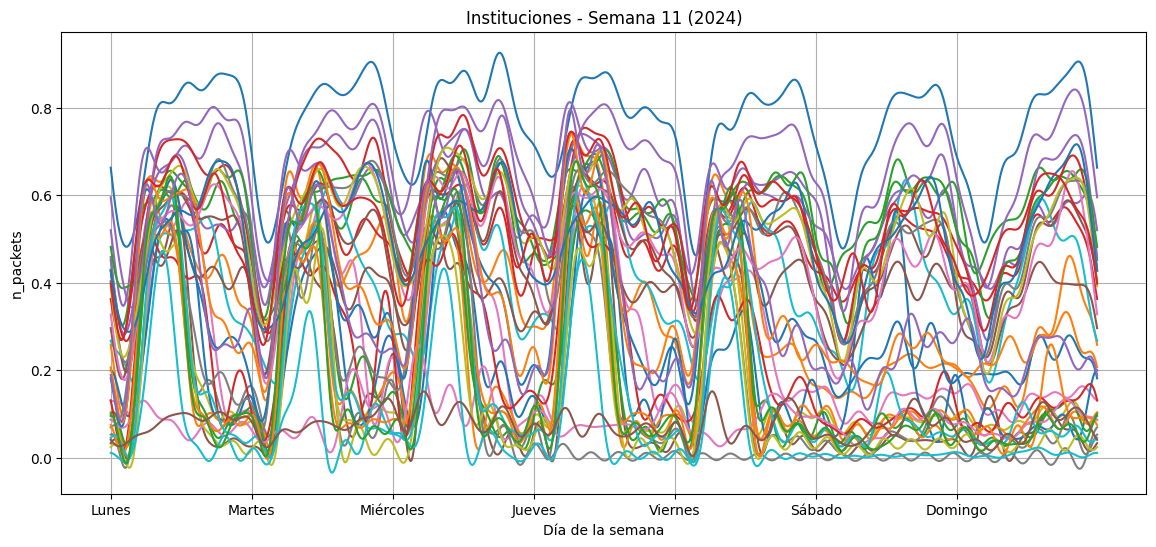

In [45]:
# ============================================================
# PASAR df_semana A DATOS FUNCIONALES Y REPRESENTACIÓN
# ============================================================

# df_semana tiene:
# - columna "time"
# - una columna por institución:
#     n_packets_0
#     n_packets_1
#     ...

# ============================================================
# 1️⃣ LIMPIAR DATAFRAME
# ============================================================

# Quitamos la columna temporal
df_semana_values = df_semana.drop(columns=["time"])

# Interpolación + rellenado de NaNs
df_semana_clean = (
    df_semana_values
    .interpolate(axis=0, limit_direction='both')
    .bfill()
    .ffill()
)

# ============================================================
# 2️⃣ CREAR BASE DE FOURIER
# ============================================================

# Número de puntos temporales de la semana
n_time = df_semana_clean.shape[0]

# Dominio temporal normalizado
t = np.linspace(0, 1, n_time)

# Número de bases Fourier
n_basis = 70

# Crear base
basis = FourierBasis(
    domain_range=(0, 1),
    n_basis=n_basis
)

# ============================================================
# 3️⃣ CREAR FDataGrid
# ============================================================

fd = FDataGrid(
    data_matrix=df_semana_clean.T.values,
    grid_points=t
)

# ============================================================
# 4️⃣ PASAR A BASE FOURIER
# ============================================================

fd_fourier = fd.to_basis(basis)

# ============================================================
# 5️⃣ EVALUAR FUNCIONES
# ============================================================

# shape -> (n_instituciones, n_time)
X = fd_fourier(t).squeeze()

# ============================================================
# 6️⃣ EJE X EN HORAS
# ============================================================

minutes_per_step = 10

x_hours = (
    np.arange(n_time)
    * minutes_per_step
    / 60
)

# Etiquetas días
days = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

ticks = np.arange(0, 7 * 24, 24)

# ============================================================
# 7️⃣ PLOT
# ============================================================

plt.figure(figsize=(14, 6))

for i, curve in enumerate(X):

    plt.plot(
        x_hours,
        curve,
        label=df_semana_clean.columns[i]
    )

plt.title(
    f"Instituciones - Semana {semana_seleccionada} ({anio_seleccionado})"
)

plt.xlabel("Día de la semana")
plt.ylabel(variable)

plt.xticks(ticks, days)

plt.grid(True)

# Opcional:
# plt.legend()

plt.show()


Mejor coeficiente de silueta: 0.469


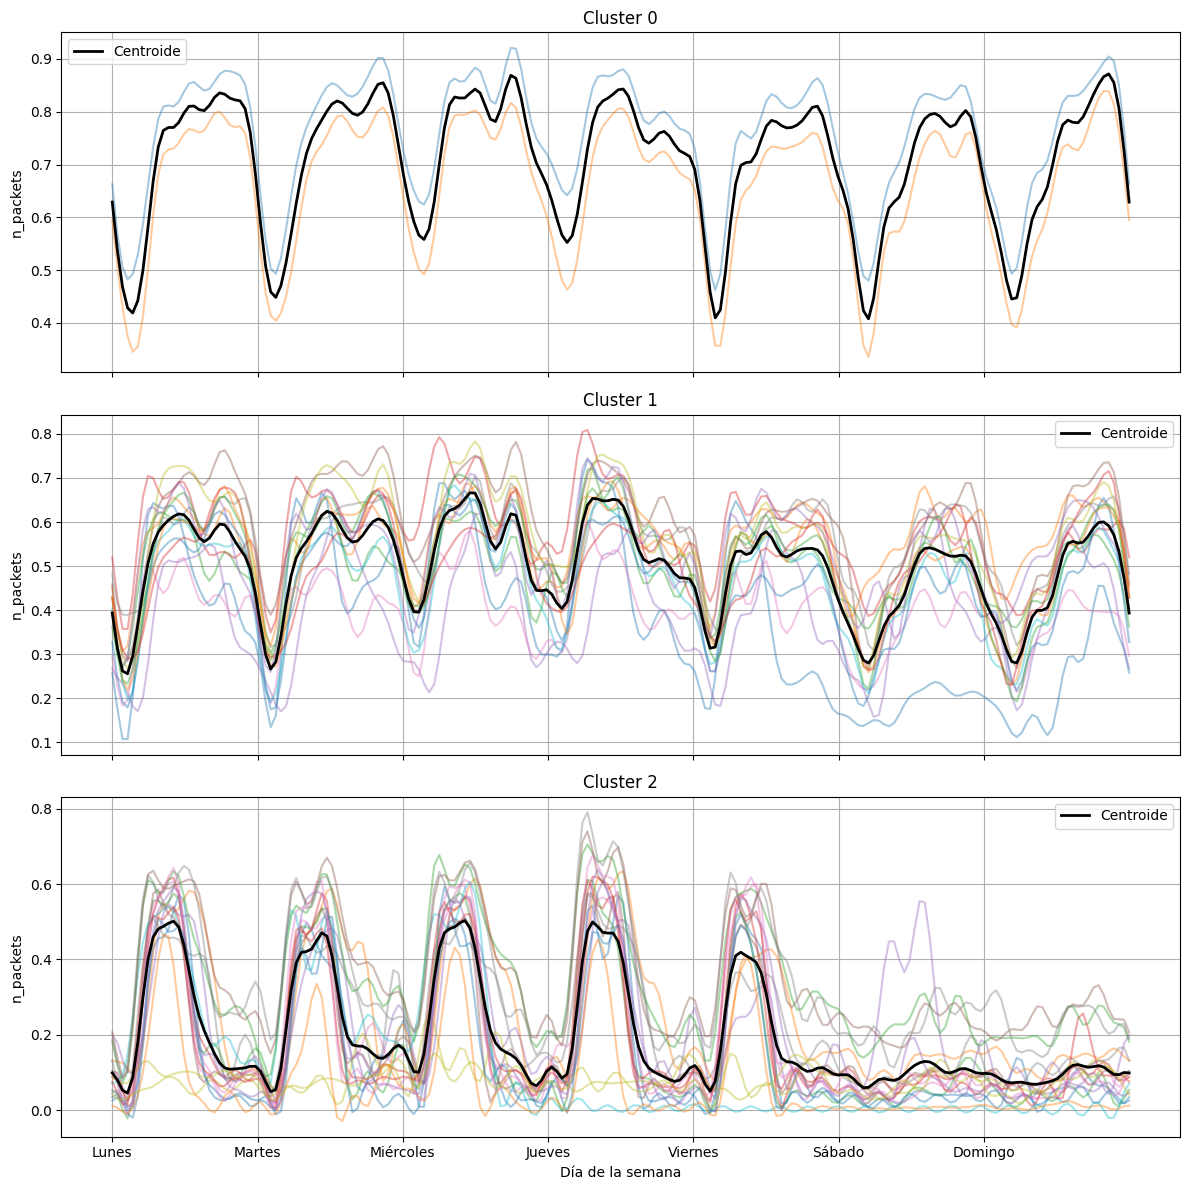


Cluster 0: 2 curvas
Curvas: ['time', 'n_packets_50']

Cluster 1: 15 curvas
Curvas: ['n_packets_0', 'n_packets_10', 'n_packets_108', 'n_packets_109', 'n_packets_161', 'n_packets_224', 'n_packets_23', 'n_packets_42', 'n_packets_48', 'n_packets_53', 'n_packets_55', 'n_packets_56', 'n_packets_57', 'n_packets_62', 'n_packets_70']

Cluster 2: 19 curvas
Curvas: ['n_packets_113', 'n_packets_139', 'n_packets_145', 'n_packets_147', 'n_packets_175', 'n_packets_198', 'n_packets_216', 'n_packets_223', 'n_packets_230', 'n_packets_235', 'n_packets_243', 'n_packets_244', 'n_packets_249', 'n_packets_34', 'n_packets_59', 'n_packets_68', 'n_packets_69', 'n_packets_80', 'n_packets_86']


In [50]:
# FUNCTIONAL K-MEANS CON COEF.SILUETA Y DISTANCIA L^2
# ============================================================
# 4) PREPARACIÓN PARA FUNCTIONAL K-MEANS
# ============================================================

# Grilla de evaluación más fina (dominio normalizado 0–1)
t_eval = np.linspace(0, 1, 200)

# Evaluar las funciones suavizadas en la nueva grilla
fd_suavizado_grid = fd_fourier.evaluate(t_eval).squeeze()
# shape: (n_semanas, len(t_eval))

fd_suavizado = skfda.FDataGrid(
    data_matrix=fd_suavizado_grid,
    grid_points=t_eval
)


# ============================================================
# 5) FUNCTIONAL K-MEANS + SELECCIÓN POR SILUETA
# ============================================================

n_clusters = 3
metric = LpDistance(p=2)
n_init = 10

best_score = -1
best_fkmeans = None

# Aplanado para silhouette (sklearn no es funcional)
X_flat = fd_suavizado.data_matrix.reshape(
    fd_suavizado.data_matrix.shape[0], -1
)

for seed in range(n_init):

    fkmeans = KMeans(
        n_clusters=n_clusters,
        metric=metric,
        random_state=seed
    )
    fkmeans.fit(fd_suavizado)

    labels = fkmeans.labels_
    score = silhouette_score(X_flat, labels, metric="euclidean")

    if score > best_score:
        best_score = score
        best_fkmeans = fkmeans


labels = best_fkmeans.labels_
centroids = best_fkmeans.cluster_centers_

print(f"Mejor coeficiente de silueta: {best_score:.3f}")


# ============================================================
# 6) PLOT DE CURVAS POR CLUSTER EN UNA SOLA FIGURA
# ============================================================

fig, axes = plt.subplots(
    n_clusters,
    1,
    figsize=(12, 4 * n_clusters),
    sharex=True
)

# Si solo hay un cluster, convertir axes en lista
if n_clusters == 1:
    axes = [axes]

# Eje temporal en horas
x_hours_eval = t_eval * (7 * 24)

# Días de la semana
days = [
    "Lunes", "Martes", "Miércoles",
    "Jueves", "Viernes",
    "Sábado", "Domingo"
]

ticks = np.arange(0, 7 * 24, 24)

# ============================================================
# PLOT DE CADA CLUSTER
# ============================================================

for i, ax in enumerate(axes):

    ax.set_title(f"Cluster {i}")

    idx_cluster = np.where(labels == i)[0]

    # Curvas del cluster
    for idx in idx_cluster:

        y = fd_suavizado.data_matrix[idx].squeeze()

        ax.plot(
            x_hours_eval,
            y,
            alpha=0.4
        )

    # Centroide
    centroid_eval = centroids[i].evaluate(t_eval).squeeze()

    ax.plot(
        x_hours_eval,
        centroid_eval,
        color="black",
        linewidth=2,
        label="Centroide"
    )

    ax.set_ylabel(variable)

    ax.grid(True)

    ax.legend()

# ============================================================
# EJE X SOLO ABAJO
# ============================================================

axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels(days)

axes[-1].set_xlabel("Día de la semana")

# Ajuste final
plt.tight_layout()

# ============================================================
# GUARDAR FIGURA
# ============================================================

plt.savefig(
    "clusters_funcionales.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7) INFORMACIÓN DE CLUSTERS (NOMBRES DE CURVAS)
# ============================================================

for i in range(n_clusters):
    cluster_idx = np.where(labels == i)[0]
    cluster_cols = df_weeks_clean.columns[cluster_idx].tolist()

    print(f"\nCluster {i}: {len(cluster_idx)} curvas")
    print("Curvas:", cluster_cols)






CLUSTER 0
→ 0 anomalías detectadas

CLUSTER 1
→ 164 anomalías detectadas

CLUSTER 2
→ 221 anomalías detectadas


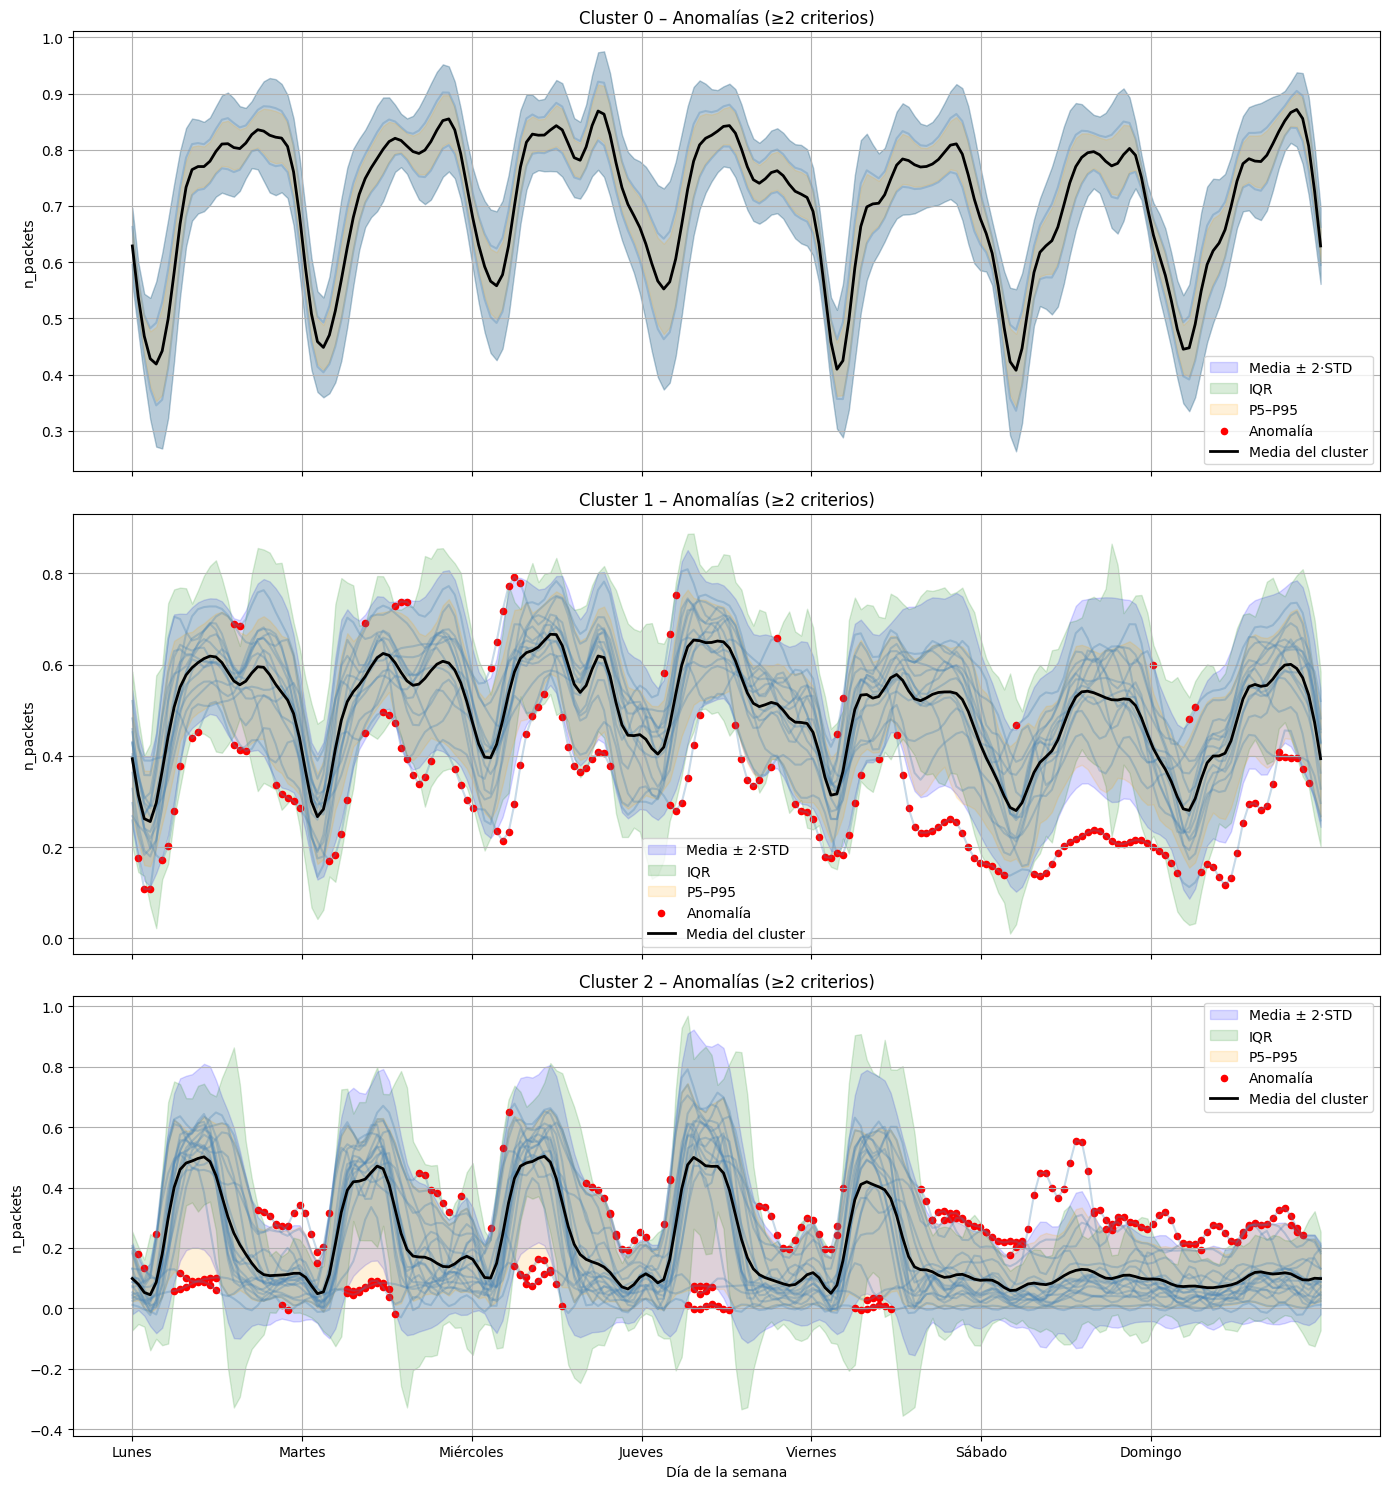


PDF guardado como:
anomalias_clusters.pdf


In [53]:
# ==========================================================
# DETECCIÓN DE ANOMALÍAS POR CLUSTER
# + PLOT CON LOS 3 CLUSTERS EN UNA SOLA FIGURA
# + GUARDADO EN PDF
# ==========================================================

k = 2
percentil_low = 5
percentil_high = 95

anomalies_by_cluster = {}

# ==========================================================
# FIGURA ÚNICA CON SUBPLOTS
# ==========================================================

fig, axes = plt.subplots(
    n_clusters,
    1,
    figsize=(14, 5 * n_clusters),
    sharex=True
)

# Si solo hay un cluster
if n_clusters == 1:
    axes = [axes]

# Días de la semana
days = [
    "Lunes", "Martes", "Miércoles",
    "Jueves", "Viernes",
    "Sábado", "Domingo"
]

ticks = np.arange(0, 7 * 24, 24)

# ==========================================================
# LOOP POR CLUSTER
# ==========================================================

for c, ax in enumerate(axes):

    print(f"\n==============================")
    print(f"CLUSTER {c}")
    print(f"==============================")

    # Índices globales del cluster
    idx_cluster = np.where(labels == c)[0]

    # Datos del cluster
    Xc = fd_suavizado.data_matrix[idx_cluster].squeeze()

    n_curvas, n_time = Xc.shape

    # ======================================================
    # 1️⃣ UMBRALES
    # ======================================================

    # Media + STD
    mean_curve = Xc.mean(axis=0)

    std_curve = Xc.std(axis=0)

    upper_std = mean_curve + k * std_curve
    lower_std = mean_curve - k * std_curve

    # IQR
    Q1 = np.percentile(Xc, 25, axis=0)
    Q3 = np.percentile(Xc, 75, axis=0)

    IQR = Q3 - Q1

    upper_iqr = Q3 + 1.5 * IQR
    lower_iqr = Q1 - 1.5 * IQR

    # Percentiles
    upper_p95 = np.percentile(Xc, percentil_high, axis=0)
    lower_p5 = np.percentile(Xc, percentil_low, axis=0)

    # ======================================================
    # 2️⃣ DETECCIÓN
    # ======================================================

    anomalies_std = (
        (Xc > upper_std) |
        (Xc < lower_std)
    )

    anomalies_iqr = (
        (Xc > upper_iqr) |
        (Xc < lower_iqr)
    )

    anomalies_p95 = (
        (Xc > upper_p95) |
        (Xc < lower_p5)
    )

    # ======================================================
    # 3️⃣ DECISIÓN FINAL
    # ======================================================

    anomalies_decided = (
        anomalies_std.astype(int)
        + anomalies_iqr.astype(int)
        + anomalies_p95.astype(int)
    ) >= 2

    # ======================================================
    # 4️⃣ DATAFRAME DE ANOMALÍAS
    # ======================================================

    records = []

    for i in range(n_curvas):

        idxs = np.where(anomalies_decided[i])[0]

        if len(idxs) > 0:

            curva_global = idx_cluster[i]

            nombre_curva = (
                df_weeks_clean.columns[curva_global]
            )

            for j in idxs:

                records.append({
                    "cluster": c,
                    "nombre_curva": nombre_curva,
                    "indice_anomalia": j
                })

    anomalies_by_cluster[c] = pd.DataFrame(records)

    print(
        f"→ {len(anomalies_by_cluster[c])} anomalías detectadas"
    )

    # ======================================================
    # 5️⃣ PLOT DEL CLUSTER
    # ======================================================

    ax.set_title(
        f"Cluster {c} – Anomalías (≥2 criterios)"
    )

    # ---------- BANDAS ----------

    ax.fill_between(
        x_hours_eval,
        lower_std,
        upper_std,
        color="blue",
        alpha=0.15,
        label=f"Media ± {k}·STD"
    )

    ax.fill_between(
        x_hours_eval,
        lower_iqr,
        upper_iqr,
        color="green",
        alpha=0.15,
        label="IQR"
    )

    ax.fill_between(
        x_hours_eval,
        lower_p5,
        upper_p95,
        color="orange",
        alpha=0.15,
        label=f"P{percentil_low}–P{percentil_high}"
    )

    # ---------- CURVAS ----------

    for i in range(n_curvas):

        ax.plot(
            x_hours_eval,
            Xc[i],
            color="steelblue",
            alpha=0.3
        )

        ax.scatter(
            x_hours_eval[anomalies_decided[i]],
            Xc[i][anomalies_decided[i]],
            color="red",
            s=20,
            label="Anomalía" if i == 0 else ""
        )

    # ---------- MEDIA ----------

    ax.plot(
        x_hours_eval,
        mean_curve,
        color="black",
        linewidth=2,
        label="Media del cluster"
    )

    ax.grid(True)

    ax.set_ylabel(
        variable
    )

    ax.legend()

# ==========================================================
# EJE X SOLO ABAJO
# ==========================================================

axes[-1].set_xticks(ticks)

axes[-1].set_xticklabels(days)

axes[-1].set_xlabel(
    "Día de la semana"
)

# ==========================================================
# AJUSTE FINAL
# ==========================================================

plt.tight_layout()

# ==========================================================
# GUARDAR PDF
# ==========================================================

plt.savefig(
    "anomalias_clusters.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# ==========================================================
# DATAFRAME FINAL
# ==========================================================

df_all_anomalies = pd.concat(
    anomalies_by_cluster.values(),
    ignore_index=True
)

print("\nPDF guardado como:")
print("anomalias_clusters.pdf")

In [44]:
# DF CON ANOMALIAS IDENTIFICADAS
records = []

for _, row in df_all_anomalies.iterrows():

    col_name = row["nombre_curva"]
    index_val = row["indice_anomalia"]
    cluster = row["cluster"]

    # =========================
    # 1️⃣ Extraer semana y año
    # =========================

    parts = col_name.split("_")

    try:
        semana = int(parts[-2])
        anio = int(parts[-1])
    except ValueError:
        # Si no se puede parsear, guardamos NaT
        records.append({
            "cluster": cluster,
            "nombre_curva": col_name,
            "indice_anomalia": index_val,
            "timestamp_real": pd.NaT
        })
        continue

    # =========================
    # 2️⃣ Valor semanal
    # =========================

    try:
        valor = df_weeks.loc[index_val, col_name]
    except KeyError:
        records.append({
            "cluster": cluster,
            "nombre_curva": col_name,
            "indice_anomalia": index_val,
            "timestamp_real": pd.NaT
        })
        continue

    # =========================
    # 3️⃣ Filtrado por semana/año
    # =========================

    df_filtrado = df_TS24_companded[
        (df_TS24_companded["time"].dt.isocalendar().week == semana) &
        (df_TS24_companded["time"].dt.year == anio)
    ]

    # =========================
    # 4️⃣ Búsqueda del timestamp
    # =========================

    # Columna base: n_flows_0
    col_base = "_".join(parts[:3])  # 'n_flows_0'

    tiempos = df_filtrado[df_filtrado[col_base] == valor]["time"]

    timestamp_real = tiempos.iloc[0] if len(tiempos) > 0 else pd.NaT

    # =========================
    # 5️⃣ Guardamos resultado
    # =========================

    records.append({
        "cluster": cluster,
        "nombre_curva": col_name,
        "indice_anomalia": index_val,
        "timestamp_real": timestamp_real
    })

# =========================
# 6️⃣ DataFrame final
# =========================

df_anomalies_with_time = pd.DataFrame(records)
df_anomalies_with_time

,cluster,nombre_curva,indice_anomalia,timestamp_real
0,1,n_packets_0,1,NaT
1,1,n_packets_0,2,NaT
2,1,n_packets_0,3,NaT
3,1,n_packets_0,19,NaT
4,1,n_packets_0,45,NaT
...,...,...,...,...
380,2,n_packets_86,70,NaT
381,2,n_packets_86,94,NaT
382,2,n_packets_86,95,NaT
383,2,n_packets_86,96,NaT
